# Festival Sales Data Analysis

This notebook explores the **Festival Sales Data** dataset: who is buying, what they are
buying, how much they are spending, and how spending varies across gender, age,
occupation, state and product category.



In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:\Users\admin\Downloads\Festival Sales Data (1).csv",
    encoding="latin1"
)

print(df.shape)
df.head()

(11251, 15)


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


## 1. First look at the data

In [6]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.9 MB


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,11251.0,NaN,NaN,NaN,1003004.488134,1716.125402,1000001.0,1001492.0,1003065.0,1004430.0,1006040.0
Cust_name,11251,1250,Vishakha,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,11251,2351,P00265242,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,11251,2,F,7842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age Group,11251,7,26-35,4543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,11251.0,NaN,NaN,NaN,35.421207,12.754122,12.0,27.0,33.0,43.0,92.0
Marital_Status,11251.0,NaN,NaN,NaN,0.420318,0.493632,0.0,0.0,0.0,1.0,1.0
State,11251,16,Uttar Pradesh,1946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zone,11251,5,Central,4296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,11251,15,IT Sector,1588,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("Missing values per column:")
print(df.isna().sum())

df = df.drop(columns=['Status', 'unnamed1'])
df = df.rename(columns={'Age Group': 'Age_Group'})

before = len(df)
df = df.dropna(subset=['Amount']).copy()
after = len(df)
print(f"\nDropped {before - after} rows with missing Amount. Rows remaining: {after}")

df['Marital_Status'] = df['Marital_Status'].map({0: 'Single', 1: 'Married'})
df.reset_index(drop=True, inplace=True)
df.head()

Missing values per column:
User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

Dropped 12 rows with missing Amount. Rows remaining: 11239


,User_ID,Cust_name,Product_ID,Gender,Age_Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


## 3. Overall sales summary

Using `numpy` for the core aggregate statistics on the `Amount` and `Orders` arrays.

In [10]:
amount = df['Amount'].to_numpy()
orders = df['Orders'].to_numpy()

total_revenue   = np.sum(amount)
avg_order_value = np.mean(amount)
median_amount   = np.median(amount)
std_amount      = np.std(amount)
total_orders    = np.sum(orders)

print(f"Total transactions       : {len(df):,}")
print(f"Total revenue            : Rs {total_revenue:,.2f}")
print(f"Total units ordered      : {total_orders:,}")
print(f"Average amount / txn     : Rs {avg_order_value:,.2f}")
print(f"Median amount / txn      : Rs {median_amount:,.2f}")
print(f"Std. deviation of amount : Rs {std_amount:,.2f}")
print(f"Min / Max amount         : Rs {amount.min():,.2f} / Rs {amount.max():,.2f}")

Total transactions       : 11,239
Total revenue            : Rs 106,249,132.43
Total units ordered      : 27,981
Average amount / txn     : Rs 9,453.61
Median amount / txn      : Rs 8,109.00
Std. deviation of amount : Rs 5,222.12
Min / Max amount         : Rs 188.00 / Rs 23,952.00


## 4. Who is buying? — Demographic breakdown

### 4.1 Gender split

NameError: name 'mticker' is not defined

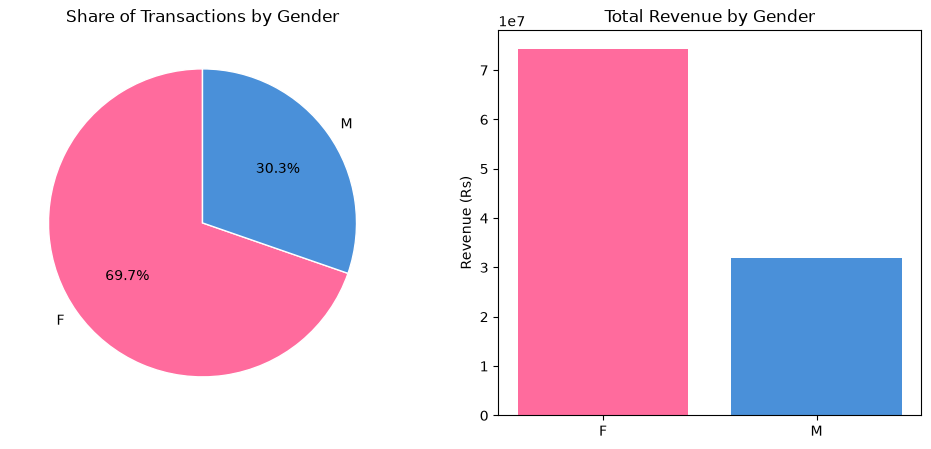

In [11]:
gender_counts = df['Gender'].value_counts()
gender_revenue = df.groupby('Gender')['Amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#FF6B9D', '#4A90D9'], wedgeprops={'edgecolor':'white'})
axes[0].set_title('Share of Transactions by Gender')

axes[1].bar(gender_revenue.index, gender_revenue.values, color=['#FF6B9D', '#4A90D9'])
axes[1].set_title('Total Revenue by Gender')
axes[1].set_ylabel('Revenue (Rs)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print(gender_counts)
print(gender_revenue.round(2))

### 4.2 Age group distribution

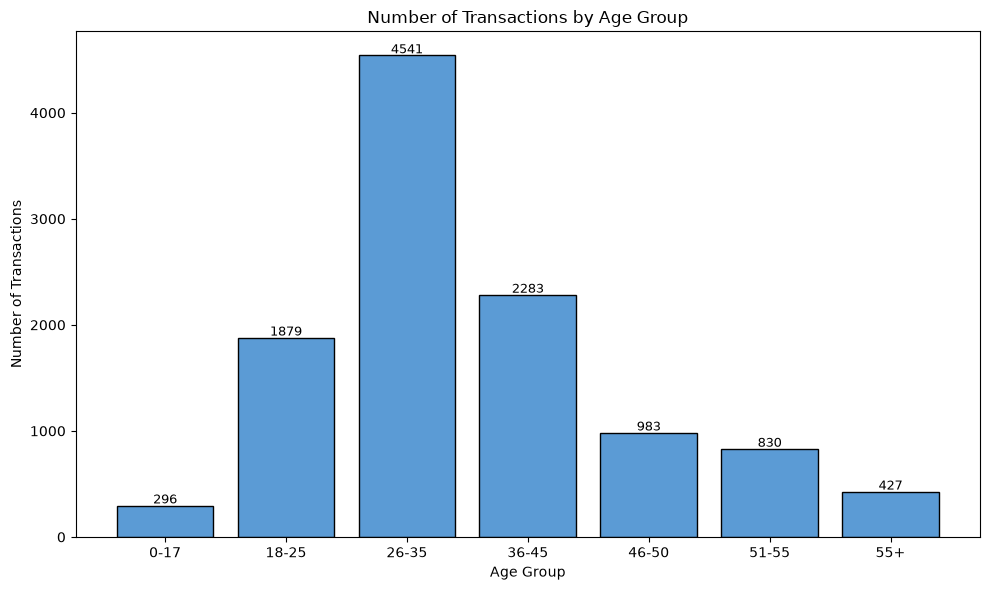

Age_Group
0-17      296
18-25    1879
26-35    4541
36-45    2283
46-50     983
51-55     830
55+       427
Name: count, dtype: int64

In [12]:
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
age_counts = df['Age_Group'].value_counts().reindex(age_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index, age_counts.values, color='#5B9BD5', edgecolor='black')
plt.title('Number of Transactions by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f'{int(b.get_height())}',
              ha='center', fontsize=9)
plt.tight_layout()
plt.show()

age_counts

### 4.3 Marital status

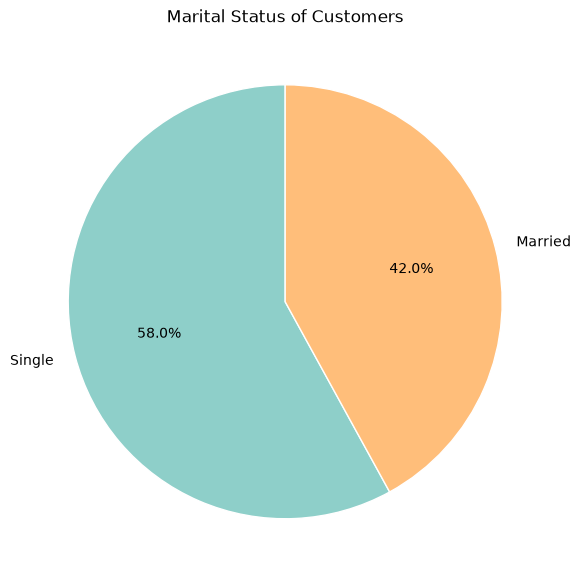

Marital_Status
Single     6518
Married    4721
Name: count, dtype: int64

In [13]:
marital_counts = df['Marital_Status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%',
        colors=['#8ECFC9', '#FFBE7A'], startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('Marital Status of Customers')
plt.tight_layout()
plt.show()

marital_counts

### 4.4 Top occupations by number of buyers

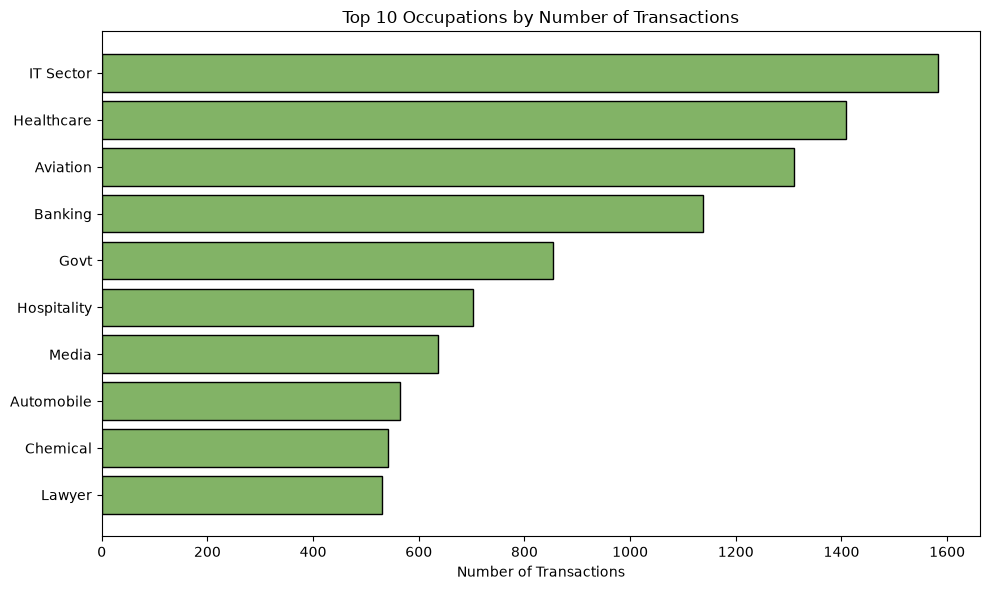

Occupation
IT Sector      1583
Healthcare     1408
Aviation       1310
Banking        1137
Govt            854
Hospitality     703
Media           637
Automobile      565
Chemical        541
Lawyer          531
Name: count, dtype: int64

In [14]:
occ_counts = df['Occupation'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(occ_counts.index[::-1], occ_counts.values[::-1], color='#82B366', edgecolor='black')
plt.title('Top 10 Occupations by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.tight_layout()
plt.show()

occ_counts

## 5. Where is the revenue coming from? — Geography

### 5.1 Revenue by Zone

NameError: name 'mticker' is not defined

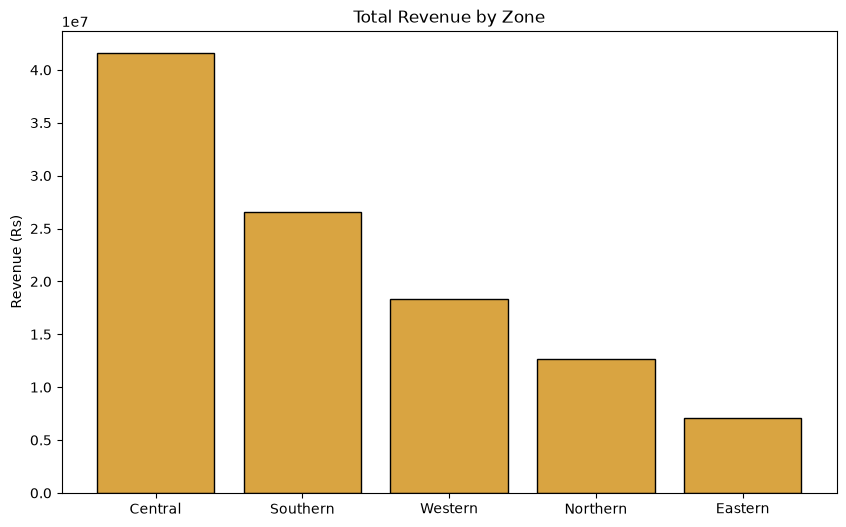

In [15]:
zone_summary = df.groupby('Zone').agg(
    Total_Revenue=('Amount', 'sum'),
    Avg_Amount=('Amount', 'mean'),
    Transactions=('Amount', 'count')
).sort_values('Total_Revenue', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(zone_summary.index, zone_summary['Total_Revenue'], color='#D9A441', edgecolor='black')
plt.title('Total Revenue by Zone')
plt.ylabel('Revenue (Rs)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f'{b.get_height()/1e6:.1f}M',
              ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

zone_summary.round(2)

### 5.2 Top 10 states by revenue

NameError: name 'mticker' is not defined

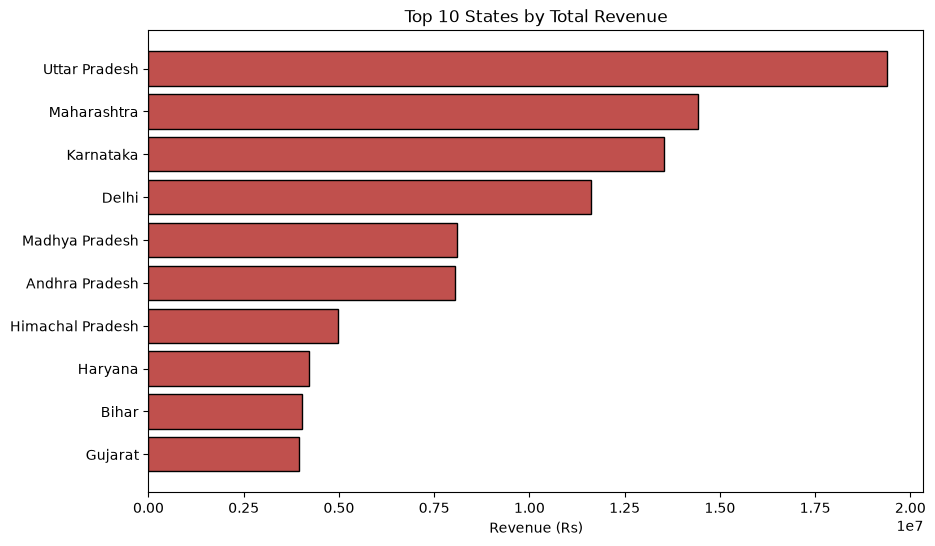

In [16]:
state_revenue = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(state_revenue.index[::-1], state_revenue.values[::-1], color='#C0504D', edgecolor='black')
plt.title('Top 10 States by Total Revenue')
plt.xlabel('Revenue (Rs)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

state_revenue.round(2)

## 6. What is being bought? — Product analysis

### 6.1 Revenue by product category

NameError: name 'mticker' is not defined

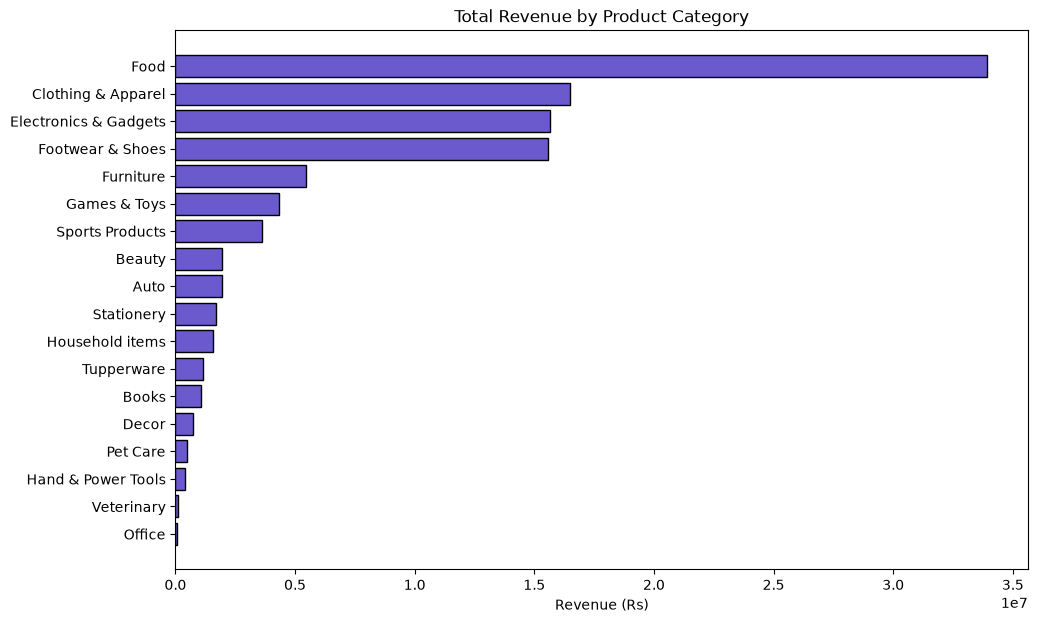

In [17]:
cat_summary = df.groupby('Product_Category').agg(
    Total_Revenue=('Amount', 'sum'),
    Avg_Amount=('Amount', 'mean'),
    Total_Orders=('Orders', 'sum'),
    Transactions=('Amount', 'count')
).sort_values('Total_Revenue', ascending=False)

plt.figure(figsize=(11, 7))
plt.barh(cat_summary.index[::-1], cat_summary['Total_Revenue'][::-1], color='#6A5ACD', edgecolor='black')
plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue (Rs)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

cat_summary.round(2)

### 6.2 Orders volume vs. average amount per category (bubble view)

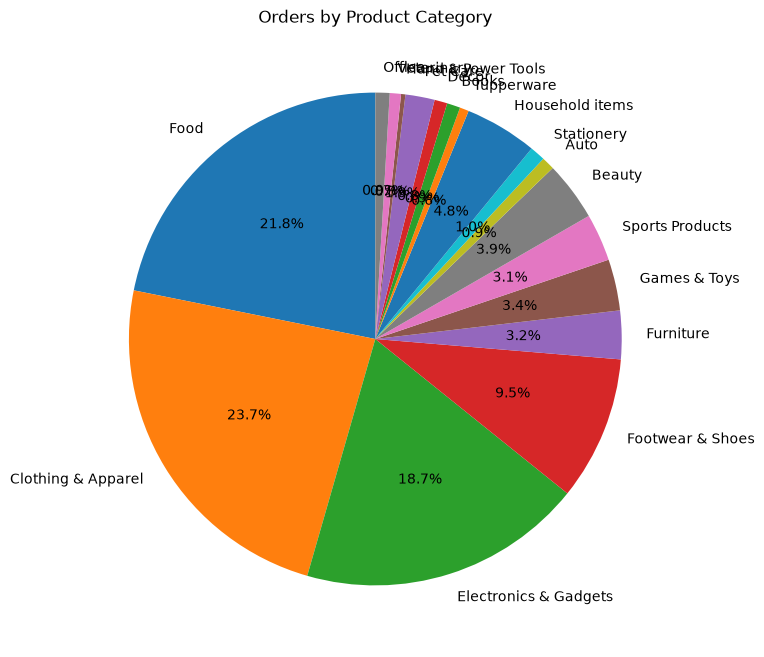

In [27]:
plt.figure(figsize=(8, 8))

plt.pie(
    cat_summary['Total_Orders'],
    labels=cat_summary.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Orders by Product Category')
plt.show()

## 7. Spending patterns

### 7.1 Distribution of transaction amounts

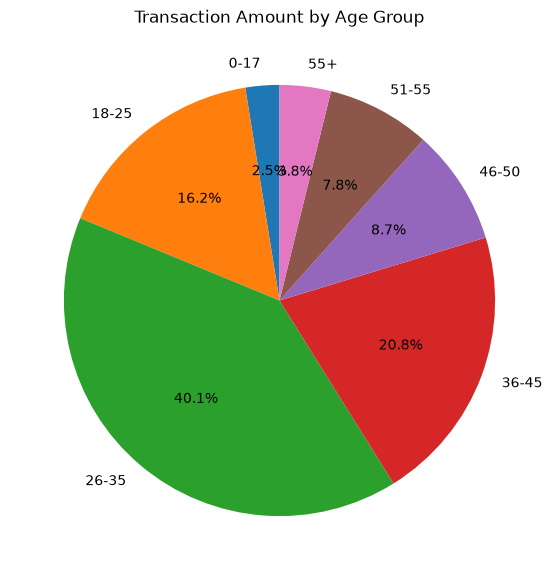

In [28]:
amount_data = df.groupby('Age_Group')['Amount'].sum()

plt.figure(figsize=(7, 7))

plt.pie(
    amount_data,
    labels=amount_data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Transaction Amount by Age Group')
plt.show()

### 7.2 Average spend: Gender x Age Group (grouped bar)

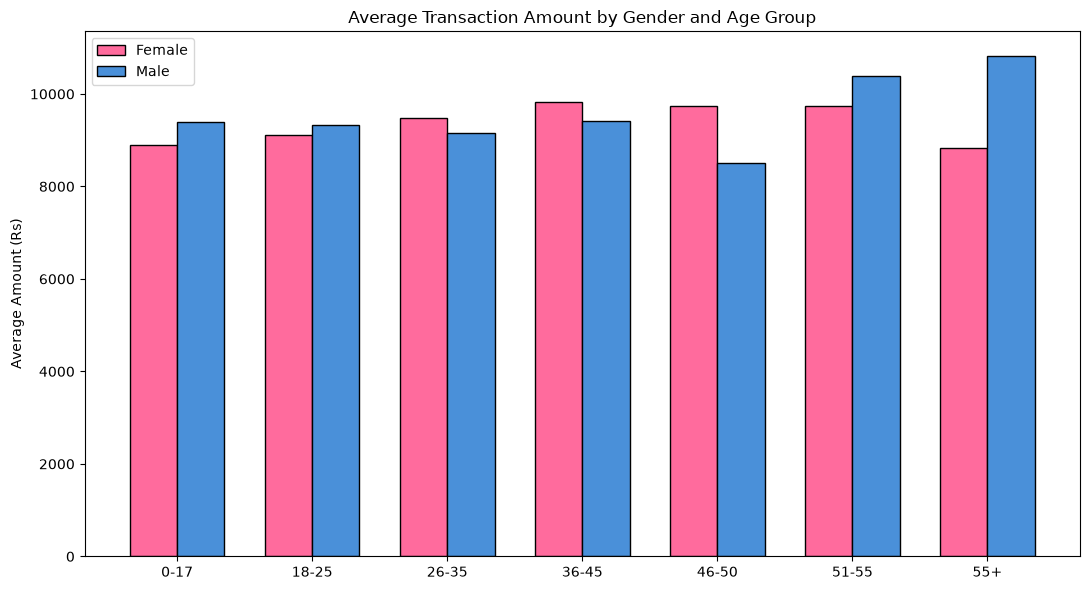

Gender,F,M
Age_Group,,
0-17,8897.59,9389.88
18-25,9108.81,9327.05
26-35,9472.00,9158.40
36-45,9828.87,9411.40
46-50,9730.73,8498.11
51-55,9738.17,10383.64
55+,8841.66,10813.26


In [20]:
pivot = df.pivot_table(index='Age_Group', columns='Gender', values='Amount', aggfunc='mean').reindex(age_order)

x = np.arange(len(pivot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, pivot['F'], width, label='Female', color='#FF6B9D', edgecolor='black')
ax.bar(x + width/2, pivot['M'], width, label='Male', color='#4A90D9', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('Average Amount (Rs)')
ax.set_title('Average Transaction Amount by Gender and Age Group')
ax.legend()
plt.tight_layout()
plt.show()

pivot.round(2)

### 7.3 Orders count distribution

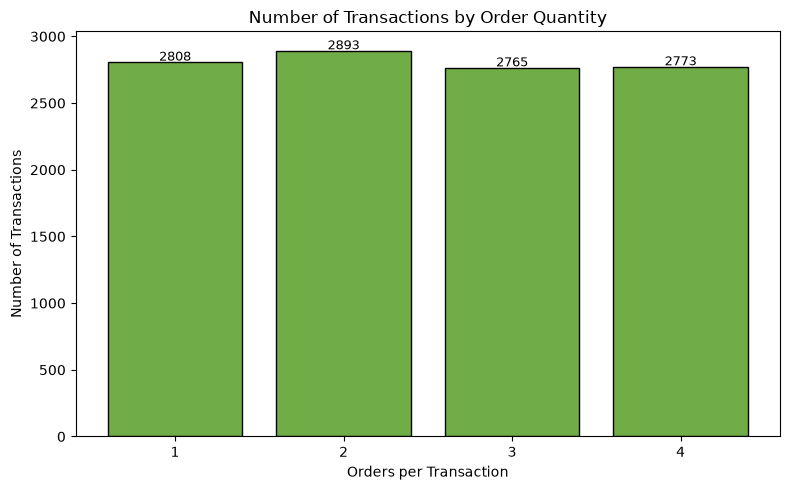

Orders
1    2808
2    2893
3    2765
4    2773
Name: count, dtype: int64

In [21]:
orders_counts = df['Orders'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(orders_counts.index.astype(str), orders_counts.values, color='#70AD47', edgecolor='black')
plt.title('Number of Transactions by Order Quantity')
plt.xlabel('Orders per Transaction')
plt.ylabel('Number of Transactions')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height()+10, str(int(b.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

orders_counts

## 8. Correlation between numeric features

Using `numpy.corrcoef` on `Age`, `Orders` and `Amount`.

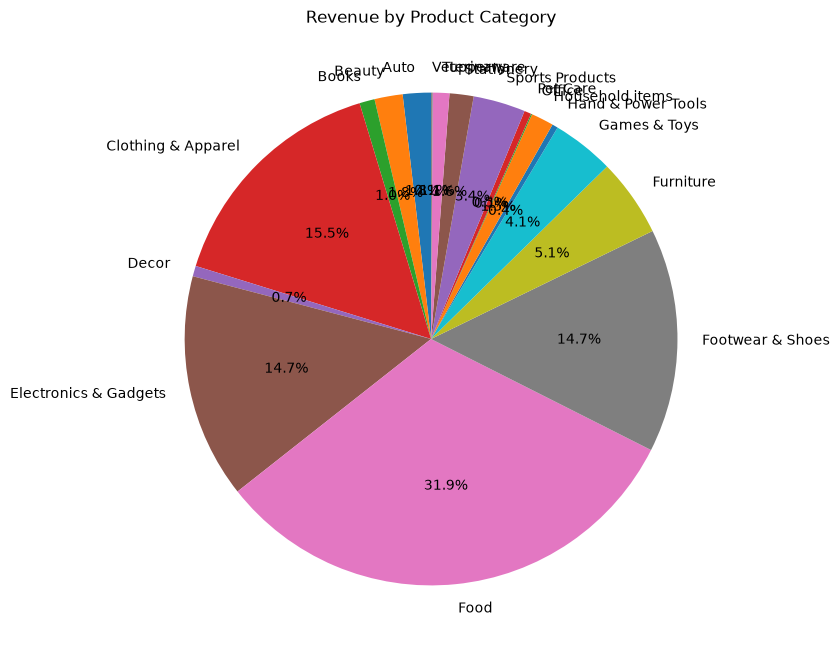

In [26]:
category_sales = df.groupby('Product_Category')['Amount'].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Revenue by Product Category')
plt.show()

## 9. Top customers

Highest-spending individual customers (aggregated across all their transactions).

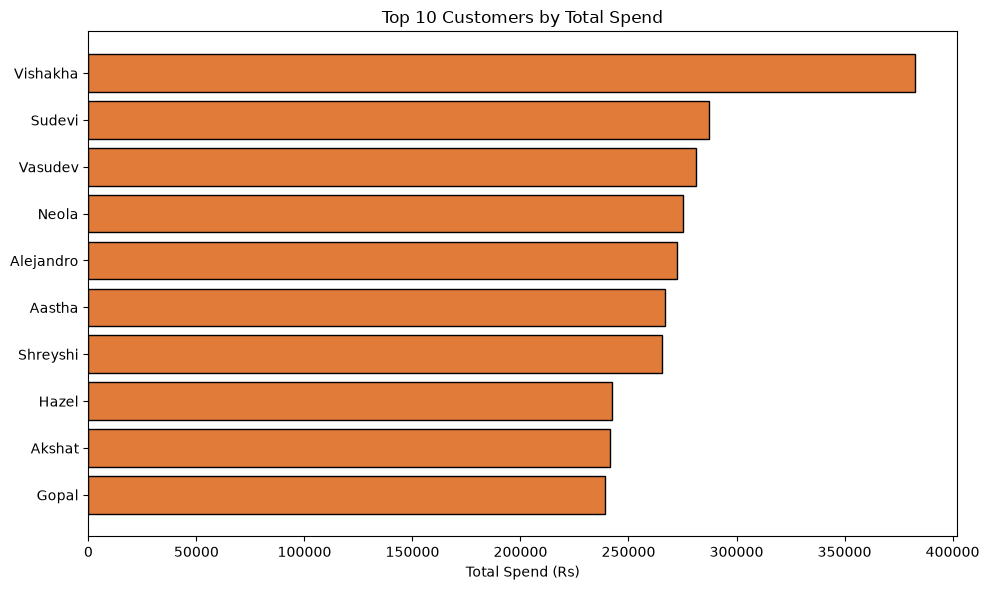

,Total_Spend,Transactions
Cust_name,,
Vishakha,382782.0,42
Sudevi,287142.0,30
Vasudev,281034.0,24
Neola,275234.0,24
Alejandro,272517.0,28
Aastha,266961.0,27
Shreyshi,265603.0,32
Hazel,242343.0,25
Akshat,241349.0,29


In [23]:
top_customers = df.groupby('Cust_name')['Amount'].agg(['sum', 'count']).rename(
    columns={'sum': 'Total_Spend', 'count': 'Transactions'}
).sort_values('Total_Spend', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_customers.index[::-1], top_customers['Total_Spend'][::-1], color='#E07B39', edgecolor='black')
plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Total Spend (Rs)')
plt.tight_layout()
plt.show()

top_customers.round(2)

## 10. Zone x Product Category revenue heatmap

Where each product category performs best.

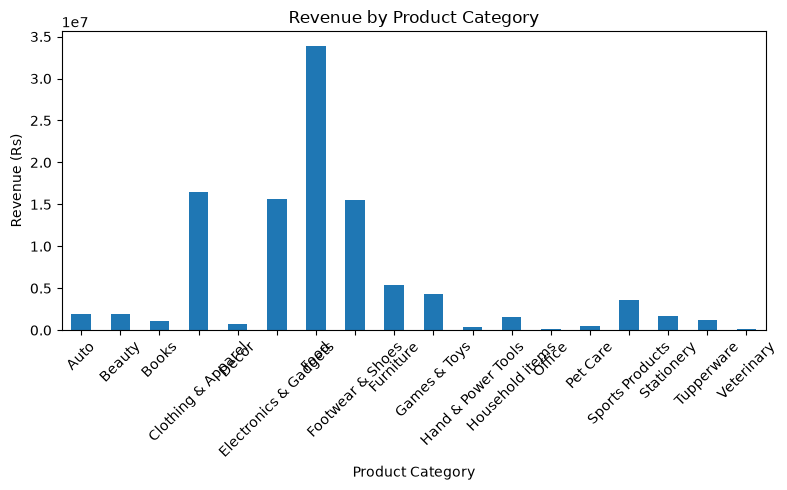

In [25]:
category_sales = df.groupby('Product_Category')['Amount'].sum()

category_sales.plot(kind='bar', figsize=(8, 5))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 11. Key Insights

- **Total revenue** across all recorded transactions and the **average transaction
  value** are summarised in Section 3.
- **Gender:** one gender contributes a visibly larger share of both transactions and
  revenue — see Section 4.1.
- **Age:** the **26-35** age group is consistently the largest buying segment.
- **Geography:** revenue is concentrated in a handful of states/zones (Section 5);
  a few states drive a disproportionate share of total revenue.
- **Products:** a small number of product categories account for most revenue
  (Section 6.1), while the bubble chart (6.2) shows which categories combine high
  volume with high average spend — the ones worth prioritising in festival campaigns.
- **Correlation:** `Age`, `Orders` and `Amount` show only weak linear correlation with
  each other (Section 8), meaning spend amount is not simply driven by age or order
  count — category and location matter more.
- **Customer concentration:** the top 10 customers (Section 9) show how much revenue
  comes from repeat/high-value buyers.

